# JioHotstar Data Analysis using Python (Pandas + Matplotlib) by Onkar Londhe

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
df = pd.read_csv("jiohotstar_data.csv")
df.head()

,User_ID,Session_ID,Age,Age_Group,Gender,Region,City,Subscription_Type,Device_Type,Genre,Content_Type,Watch_Time_Minutes,Rating,Date
0,37318,S760247,34,25-34,Male,North,Bangalore,Free,Tablet,Sports,Series,96,3,2023-02-21
1,85696,S195097,32,25-34,Male,North,Pune,Premium,Mobile,Sports,Series,143,4,2023-02-24
2,95019,S834921,18,18-24,Male,West,Mumbai,VIP,Laptop,Series,Series,58,1,2024-09-18
3,86394,S938916,16,13-17,Female,West,Kolkata,VIP,Smart TV,Movies,Live Sports,110,2,2024-01-08
4,22164,S259351,45,45-54,Male,Central,Pune,Premium,Laptop,Sports,Live Sports,232,4,2024-10-19


In [3]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   User_ID             100000 non-null  int64 
 1   Session_ID          100000 non-null  object
 2   Age                 100000 non-null  int64 
 3   Age_Group           100000 non-null  object
 4   Gender              100000 non-null  object
 5   Region              100000 non-null  object
 6   City                100000 non-null  object
 7   Subscription_Type   100000 non-null  object
 8   Device_Type         100000 non-null  object
 9   Genre               100000 non-null  object
 10  Content_Type        100000 non-null  object
 11  Watch_Time_Minutes  100000 non-null  int64 
 12  Rating              100000 non-null  int64 
 13  Date                100000 non-null  object
dtypes: int64(4), object(10)
memory usage: 10.7+ MB


In [4]:
# 
df.describe()

,User_ID,Age,Watch_Time_Minutes,Rating
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,54919.135660,36.510500,122.312650,3.003250
std,25938.701102,13.866193,67.884828,1.415154
min,10000.000000,13.000000,5.000000,1.000000
25%,32524.750000,24.000000,64.000000,2.000000
50%,54932.000000,36.000000,122.000000,3.000000
75%,77196.000000,49.000000,181.000000,4.000000
max,99999.000000,60.000000,240.000000,5.000000


In [5]:
# Check Missing Values
df.isnull().sum()

User_ID               0
Session_ID            0
Age                   0
Age_Group             0
Gender                0
Region                0
City                  0
Subscription_Type     0
Device_Type           0
Genre                 0
Content_Type          0
Watch_Time_Minutes    0
Rating                0
Date                  0
dtype: int64

In [6]:
# Value Counts
df['Genre'].value_counts()

Genre
Documentary    16928
Sports         16819
Reality        16753
Kids           16578
Series         16541
Movies         16381
Name: count, dtype: int64

# key Performance

In [29]:
total_users = df['User_ID'].nunique()
total_watch_time = df['Watch_Time_Minutes'].sum()
avg_watch_time = df['Watch_Time_Minutes'].mean()

print("Total Users:", total_users)
print("Total Watch Time:", total_watch_time)
print("Average Watch Time:", avg_watch_time)

Total Users: 60306
Total Watch Time: 12231265
Average Watch Time: 122.31265


# Exploratory Data Analysis (EDA)

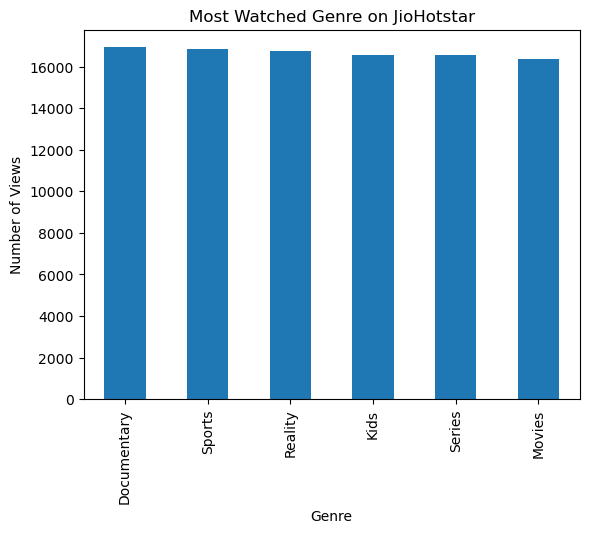

In [8]:
# Bar Chart – Genre Popularity
import matplotlib.pyplot as plt

df['Genre'].value_counts().plot(kind='bar')
plt.title("Most Watched Genre on JioHotstar")
plt.xlabel("Genre")
plt.ylabel("Number of Views")
plt.show()



Insight:
    Movies and sports dominate overall viewership on the platform.
    Entertainment-focused content attracts the highest audience engagement.
    This indicates strong demand for blockbuster movies and live sports streaming.

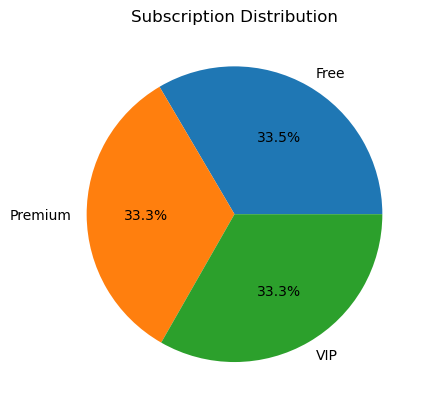

In [9]:
# Pie Chart – Subscription Distribution
df['Subscription_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Subscription Distribution")
plt.ylabel("")
plt.show()

Insight:
    A significant portion of users are on the free subscription plan, indicating a large ad-supported user base.
    Premium users contribute to higher revenue and typically show higher watch time.
    Converting free users to paid plans could increase platform profitability.

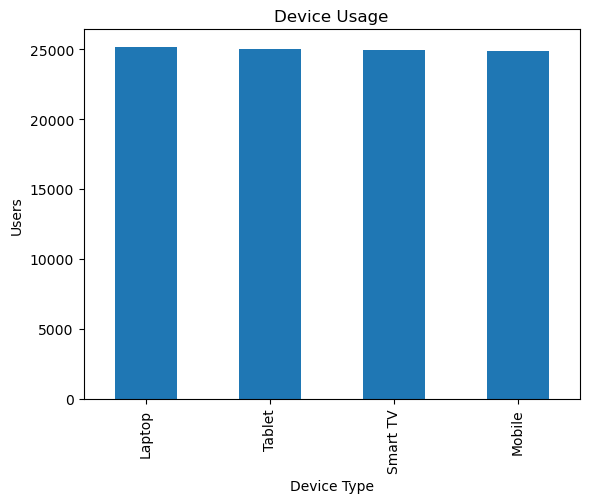

In [10]:
# Bar Chart – Device Usage
df['Device_Type'].value_counts().plot(kind='bar')
plt.title("Device Usage")
plt.xlabel("Device Type")
plt.ylabel("Users")
plt.show()

Insight:
    Mobile devices account for the majority of streaming sessions.
    This shows users prefer on-the-go entertainment.
    Optimizing mobile app performance and user experience is crucial for engagement.

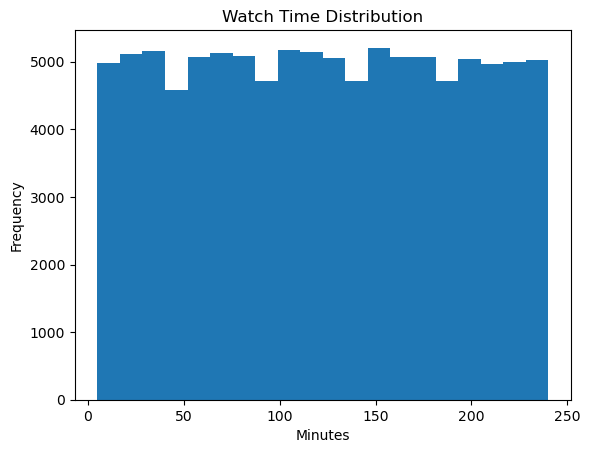

In [11]:
# Histogram – Watch Time Distribution
df['Watch_Time_Minutes'].plot(kind='hist', bins=20)
plt.title("Watch Time Distribution")
plt.xlabel("Minutes")
plt.show()

Insight:
    Most users watch content for moderate durations, typically between short and mid-length sessions.
    A smaller group of users shows very high watch times, indicating binge-watching behavior.
    Personalized recommendations could increase session duration.

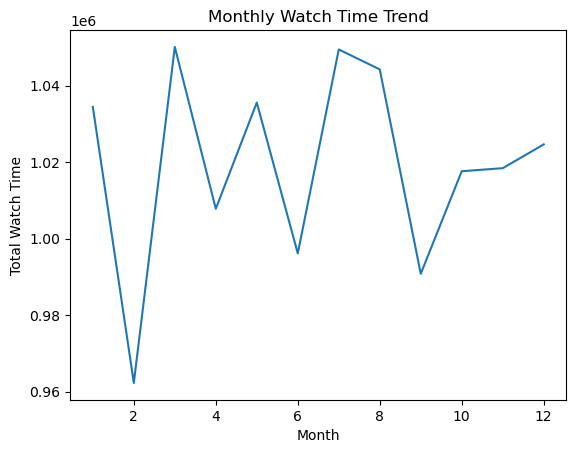

In [12]:
# Line Chart – Monthly Watch Trends
df['Date'] = pd.to_datetime(df['Date'])

monthly_watch = df.groupby(df['Date'].dt.month)['Watch_Time_Minutes'].sum()

monthly_watch.plot(kind='line')
plt.title("Monthly Watch Time Trend")
plt.xlabel("Month")
plt.ylabel("Total Watch Time")
plt.show()

Insight:
    Watch time fluctuates throughout the year with noticeable peaks.
    Peaks may correspond to major sports events, movie releases, or holiday seasons.
    Strategic content releases during these periods can maximize engagement.

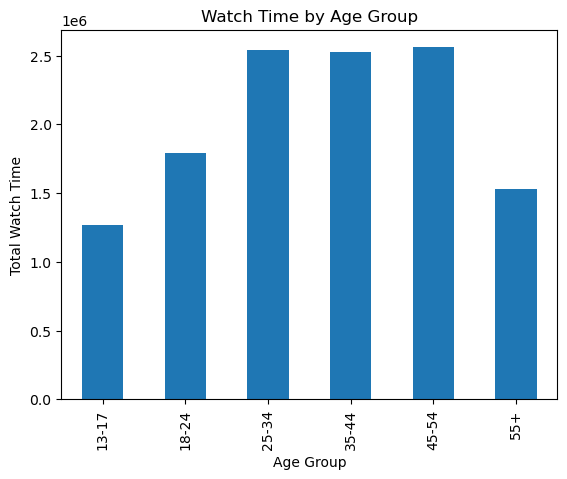

In [13]:
# Bar Chart – Age Group Engagement
df.groupby('Age_Group')['Watch_Time_Minutes'].sum().plot(kind='bar')
plt.title("Watch Time by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Watch Time")
plt.show()

Insight:
    Younger audiences (18–34) contribute the highest watch time.
    This demographic is the most active streaming audience.
    Content targeted toward youth such as web series and sports can increase engagement.

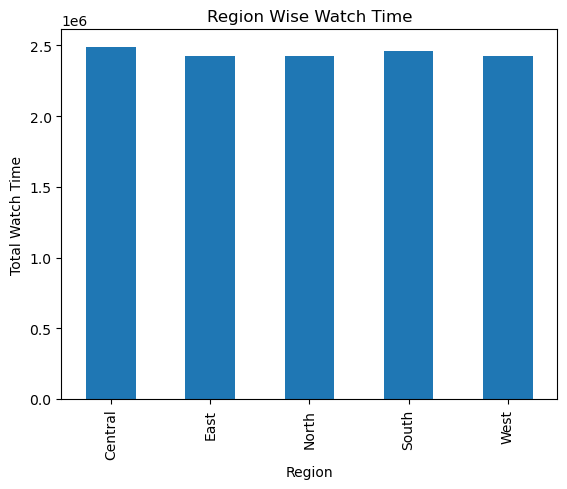

In [14]:
# Bar Chart – Region Wise Streaming
df.groupby('Region')['Watch_Time_Minutes'].sum().plot(kind='bar')
plt.title("Region Wise Watch Time")
plt.xlabel("Region")
plt.ylabel("Total Watch Time")
plt.show()

In [ ]:
Insight:
    Some regions show significantly higher streaming activity than others.
    Urban regions typically generate higher watch time due to better internet access.
    Regional content could improve engagement in underperforming areas.

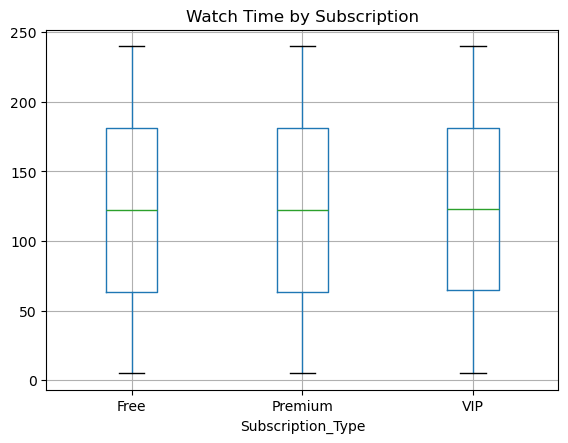

In [15]:
# Box Plot – Watch Time by Subscription
df.boxplot(column='Watch_Time_Minutes', by='Subscription_Type')
plt.title("Watch Time by Subscription")
plt.suptitle("")
plt.show()

Insight:
    Premium subscribers tend to watch more content compared to free users.
    Paid users are generally more engaged and spend more time on the platform.
    This highlights the importance of premium subscription features.

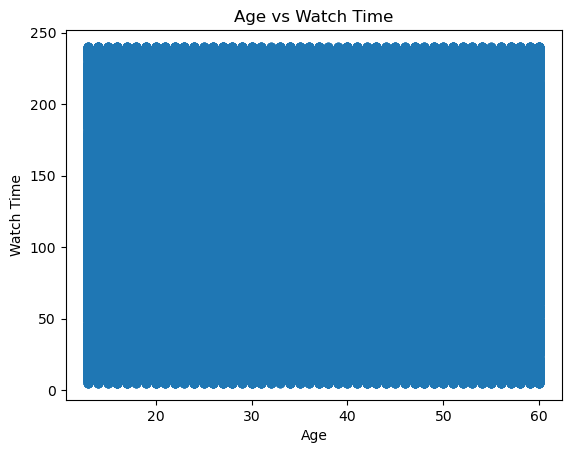

In [16]:
# Scatter Plot – Age vs Watch Time
plt.scatter(df['Age'], df['Watch_Time_Minutes'])
plt.xlabel("Age")
plt.ylabel("Watch Time")
plt.title("Age vs Watch Time")
plt.show()

Insight:
    Younger users tend to have slightly higher watch time.
    Older users show more moderate viewing patterns.
    Content personalization based on age groups can improve user retention.

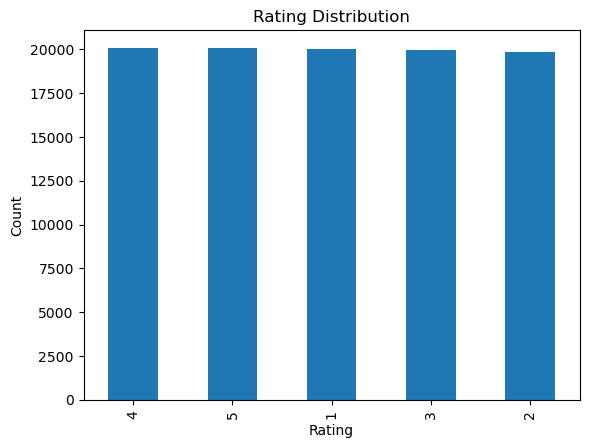

In [17]:
# Rating Distribution
df['Rating'].value_counts().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Insight:
    Most content ratings cluster around higher ratings (4–5), indicating positive user satisfaction.
    Highly rated content can be promoted more to increase watch time.
    Low-rated content may require quality improvements.

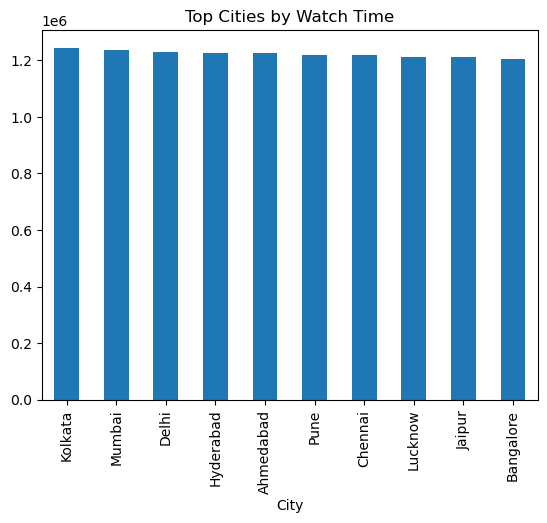

In [18]:
# Top Cities by Watch Time
df.groupby('City')['Watch_Time_Minutes'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Cities by Watch Time")
plt.show()

Insight:
    Major metropolitan cities generate the highest streaming activity.
    Cities with higher population and internet penetration dominate viewership.
    Targeted marketing campaigns in these cities can drive subscriptions.

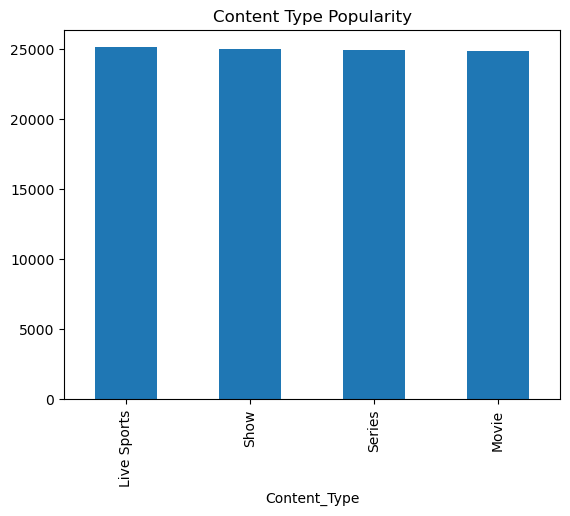

In [19]:
# Content Type Popularity
df['Content_Type'].value_counts().plot(kind='bar')
plt.title("Content Type Popularity")
plt.show()

Insight:
    Movies and series are the most consumed content types.
    Live sports events also attract significant engagement during broadcast periods.
    Investing in exclusive content can increase platform competitiveness.

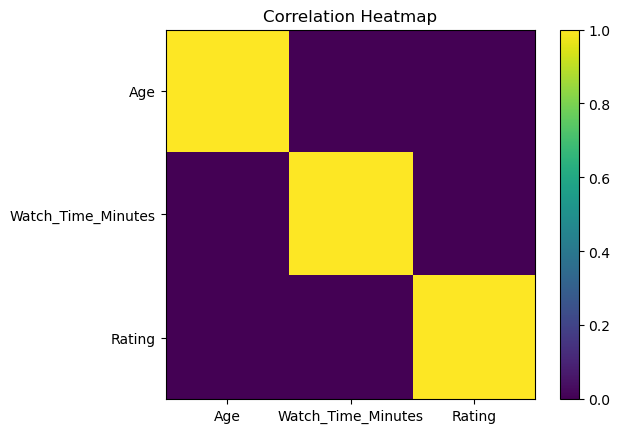

In [20]:
# Correlation Heatmap
corr = df[['Age','Watch_Time_Minutes','Rating']].corr()

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
Insight:
    Watch time may show moderate correlation with user age or rating.
    Positive correlation indicates that certain demographic groups spend more time streaming.
    These relationships help in improving recommendation algorithms.

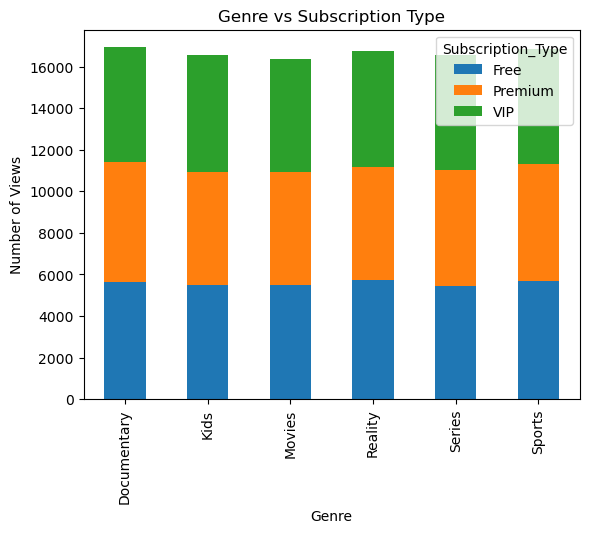

In [21]:
# Stacked Bar Chart (Genre vs Subscription)
genre_sub = pd.crosstab(df['Genre'], df['Subscription_Type'])

genre_sub.plot(kind='bar', stacked=True)

plt.title("Genre vs Subscription Type")
plt.xlabel("Genre")
plt.ylabel("Number of Views")
plt.show()

Insight:
    Premium users tend to watch high-value content such as sports and movies.
    Free users may consume more general entertainment content.
    This insight can help tailor subscription plans and content strategy.

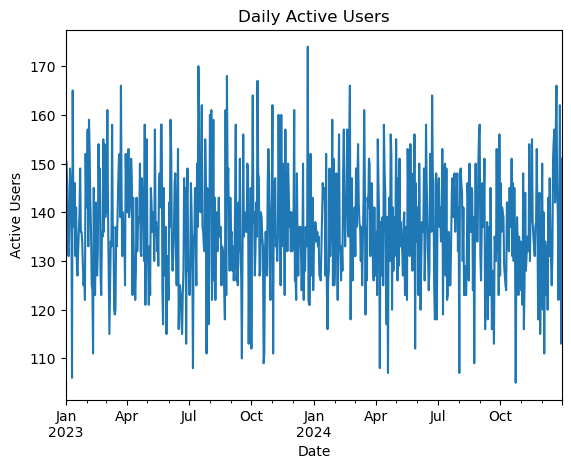

In [22]:
# Daily Active Users Trend
df['Date'] = pd.to_datetime(df['Date'])

daily_users = df.groupby('Date')['User_ID'].nunique()

daily_users.plot(kind='line')

plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Active Users")
plt.show()

Insight:
    User activity fluctuates daily with noticeable peaks.
    Weekends often show higher streaming activity compared to weekdays.
    Promotions and new releases during peak days can maximize engagement.

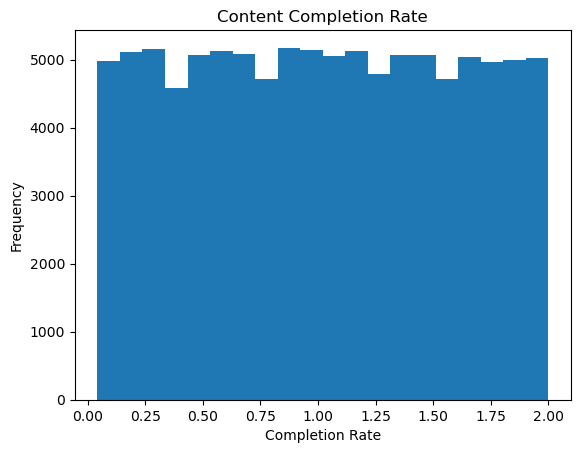

In [23]:
# Content Completion Rate
df['Completion_Rate'] = df['Watch_Time_Minutes'] / 120

df['Completion_Rate'].plot(kind='hist', bins=20)

plt.title("Content Completion Rate")
plt.xlabel("Completion Rate")
plt.show()

Insight:
    High completion rates indicate engaging content.
    Low completion rates may indicate user drop-off or less engaging content.
    Content creators can use this insight to improve storytelling and pacing.

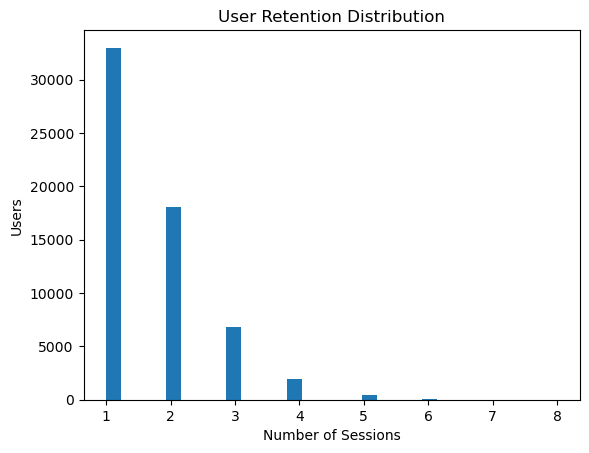

In [24]:
# User Retention Analysis
user_sessions = df.groupby('User_ID')['Session_ID'].count()

user_sessions.plot(kind='hist', bins=30)

plt.title("User Retention Distribution")
plt.xlabel("Number of Sessions")
plt.ylabel("Users")
plt.show()

Insight:
    A portion of users return multiple times, showing strong platform loyalty.
    Some users have very few sessions, indicating potential churn.
    Personalized recommendations and notifications can improve retention.

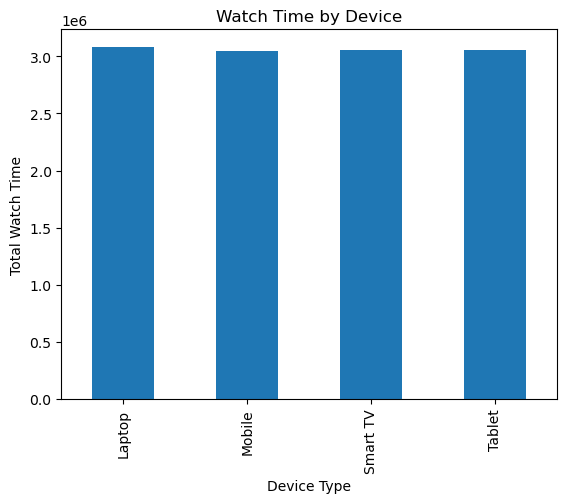

In [25]:
# Watch Time per Device
device_watch = df.groupby('Device_Type')['Watch_Time_Minutes'].sum()

device_watch.plot(kind='bar')

plt.title("Watch Time by Device")
plt.xlabel("Device Type")
plt.ylabel("Total Watch Time")
plt.show()

Insight:
    Mobile devices generate the largest share of watch time.
    Smart TVs may show longer viewing sessions due to home entertainment usage.
    Device-specific optimization can improve user experience.

## Conclusion

The JioHotstar Data Analysis project explored user streaming behavior, content preferences, subscription patterns, and platform engagement using Python, Pandas, and Matplotlib.

The analysis revealed that movies and sports content generate the highest engagement, while mobile devices dominate streaming usage. Premium subscribers tend to spend more watch time compared to free users, indicating higher engagement among paid users.

These insights demonstrate how data analytics can help streaming platforms understand user behavior, improve content strategy, and optimize subscription models.

Overall, this project highlights the importance of data-driven decision making in enhancing user experience and increasing platform growth.


## Business Recommendations

- Focus on investing in high-demand content such as movies and live sports to increase user engagement.  
- Improve the mobile streaming experience since most users access the platform through mobile devices.  
- Encourage free users to upgrade to premium plans by offering exclusive content and promotional trials.  
- Use personalized recommendation systems to suggest relevant content and increase watch time.  
- Expand regional and youth-focused content to attract a wider audience and improve user retention.
